# Phase 1 new-experiment batch — Experiments A & B (statistical analysis)

Companion notebook to `reports/phase1_newexperiments_preregistration.md`.
The tests implemented here are exactly the preregistered ones; statistics
helpers are imported from `experiments/analyze_phase1_newexperiments.py`
(numpy-only implementations, seeded RNG 20260815) so the notebook and the
headless analyzer share one source of truth.

- **Experiment A** — long-window emergence at 4,096 tapes / 100,000 epochs:
  conserved arms m0.5/m2/m16 (5 seeds each) + no-conservation control (5 seeds).
- **Experiment B** — conserved continuation of the natural Phase 0 seed-0
  checkpoint (131,072 tapes, 8,000 epochs, offset 2,433).

Re-run with: `uv run jupyter lab notebooks/` (kernel: `.venv` python3).

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from experiments.analyze_phase1_newexperiments import (
    LONGWINDOW,
    CONTINUATION,
    CONTROL_DIR,
    ROOT,
    block_bootstrap_difference,
    bootstrap_ci,
    entropy_transition,
    fisher_exact_2x2,
    mannwhitney_u,
    spearman,
)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)
RNG = np.random.default_rng(20260815)

## 1. Load runs (only manifests with `exit_status == success`)

In [2]:
def load_conserved(run_dir: Path) -> dict:
    manifest = json.loads((run_dir / "manifest.json").read_text())
    aggregate = pd.read_csv(run_dir / "aggregate.csv")
    writes = pd.read_csv(run_dir / "writes.csv")
    transition, first_epoch, max_entropy = entropy_transition(aggregate)
    cfg = manifest["config"]
    return {
        "arm": f"m{cfg['pool_multiplier']:g}",
        "kind": "conserved",
        "seed": cfg["seed"],
        "epochs": cfg["epochs"],
        "entropy_transition": transition,
        "first_transition_epoch": first_epoch,
        "max_high_order_entropy": max_entropy,
        "final_high_order_entropy": aggregate["high_order_entropy"].iloc[-1],
        "max_dominant_fraction": aggregate["dominant_tape_fraction"].max(),
        "final_dominant_fraction": aggregate["dominant_tape_fraction"].iloc[-1],
        "overall_blocked_fraction": (writes["execution_writes_blocked"] + writes["mutation_writes_blocked"]).sum() / max(1, (writes["execution_writes_success"] + writes["execution_writes_blocked"] + writes["mutation_writes_success"] + writes["mutation_writes_blocked"]).sum()),
        "run_dir": str(run_dir.relative_to(ROOT)),
        "_aggregate": aggregate,
        "_writes": writes,
    }


def load_control(csv_path: Path, arm: str | None = None, seed: int | None = None) -> dict:
    aggregate = pd.read_csv(csv_path)
    transition, first_epoch, max_entropy = entropy_transition(aggregate)
    return {
        "arm": arm or "control",
        "kind": "control",
        "seed": seed if seed is not None else int(csv_path.stem.split("_s")[-1]),
        "epochs": len(aggregate),
        "entropy_transition": transition,
        "first_transition_epoch": first_epoch,
        "max_high_order_entropy": max_entropy,
        "final_high_order_entropy": aggregate["high_order_entropy"].iloc[-1],
        "max_dominant_fraction": aggregate["dominant_tape_fraction"].max(),
        "final_dominant_fraction": aggregate["dominant_tape_fraction"].iloc[-1],
        "overall_blocked_fraction": 0.0,
        "run_dir": str(csv_path.relative_to(ROOT)),
        "_aggregate": aggregate,
        "_writes": None,
    }


rows = []
for run_dir in sorted(LONGWINDOW.glob("p1_m*_n4096_s*")):
    if json.loads((run_dir / "manifest.json").read_text()).get("exit_status") == "success":
        rows.append(load_conserved(run_dir))
for csv_path in sorted(CONTROL_DIR.glob("A_control_n4096_s*.csv")):
    rows.append(load_control(csv_path))
a_runs = pd.DataFrame([{k: v for k, v in row.items() if not k.startswith("_")} for row in rows])
trajectories = {row["run_dir"]: (row["_aggregate"], row["_writes"]) for row in rows}
print(f"Experiment A: {len(a_runs)} completed runs")
a_runs[["arm", "seed", "entropy_transition", "first_transition_epoch", "max_high_order_entropy", "final_dominant_fraction", "overall_blocked_fraction"]]

Experiment A: 20 completed runs


,arm,seed,entropy_transition,first_transition_epoch,max_high_order_entropy,final_dominant_fraction,overall_blocked_fraction
0,m0.5,0,False,NaN,0.503376,0.000244,0.054780
1,m0.5,1,False,NaN,0.466107,0.000244,0.052752
2,m0.5,2,False,NaN,0.439842,0.000732,0.049499
3,m0.5,3,False,NaN,0.424220,0.000244,0.072007
4,m0.5,4,True,35501.0,1.226487,0.000244,0.050336
5,m16,0,True,90401.0,5.953695,0.002686,0.000119
6,m16,1,False,NaN,0.337898,0.000244,0.000117
7,m16,2,False,NaN,0.336284,0.000244,0.000175
8,m16,3,False,NaN,0.366837,0.000244,0.000079
9,m16,4,False,NaN,0.412793,0.000244,0.000033


## 2. Experiment A hypotheses

### A1 — horizon sufficiency (control)
Emergence in at least 1/5 control seeds within 100,000 epochs.

In [3]:
control = a_runs[a_runs["arm"] == "control"]
control_emergence = int(control["entropy_transition"].sum())
print(f"A1: control emergences = {control_emergence}/{len(control)}")
print(f"     first-transition epochs: {sorted(control['first_transition_epoch'].dropna().astype(int).tolist())}")
for seed, first in zip(control.loc[control["entropy_transition"], "seed"], control.loc[control["entropy_transition"], "first_transition_epoch"]):
    print(f"     seed {seed}: transition at epoch {int(first)}")

A1: control emergences = 1/5
     first-transition epochs: [63701]
     seed 2: transition at epoch 63701


### A2 — conservation suppresses emergence (one-sided Fisher exact on m2 vs control)

In [4]:
m2 = a_runs[a_runs["arm"] == "m2"]
m2_emergence = int(m2["entropy_transition"].sum())
odds, p_a2 = fisher_exact_2x2(control_emergence, len(control) - control_emergence, m2_emergence, len(m2) - m2_emergence, one_sided=True)
print(f"A2: m2 emergences {m2_emergence}/{len(m2)} vs control {control_emergence}/{len(control)}")
print(f"     one-sided Fisher exact: OR = {odds:.3f}, p = {p_a2:.4f}")

A2: m2 emergences 1/5 vs control 1/5
     one-sided Fisher exact: OR = 1.000, p = 0.7778


### A3 — scarcity ordering: multiplier vs max high-order entropy (Spearman)

In [5]:
conserved = a_runs[a_runs["arm"] != "control"].copy()
conserved["multiplier"] = conserved["arm"].str[1:].astype(float)
rho_a3, p_a3 = spearman(conserved["multiplier"].to_numpy(), conserved["max_high_order_entropy"].to_numpy())
print(f"A3: Spearman rho = {rho_a3:.3f}, p = {p_a3:.4f} (n = {len(conserved)})")
conserved.groupby("arm")["max_high_order_entropy"].agg(["mean", "min", "max"])

A3: Spearman rho = -0.302, p = 1.0000 (n = 15)


,mean,min,max
arm,,,
m0.5,0.612006,0.424220,1.226487
m16,1.481502,0.336284,5.953695
m2,0.879723,0.468668,1.632473


### A4 — blocked-write scarcity curve reproduces (Spearman, multiplier vs blocked fraction)

In [6]:
rho_a4, p_a4 = spearman(conserved["multiplier"].to_numpy(), conserved["overall_blocked_fraction"].to_numpy())
print(f"A4: Spearman rho = {rho_a4:.3f}, p = {p_a4:.4f} (n = {len(conserved)})")
conserved.groupby("arm")["overall_blocked_fraction"].agg(["mean", "min", "max"])

A4: Spearman rho = -0.945, p = 0.0000 (n = 15)


,mean,min,max
arm,,,
m0.5,0.055875,0.049499,0.072007
m16,0.000105,0.000033,0.000175
m2,0.021185,0.014671,0.040918


## 3. Experiment A trajectories

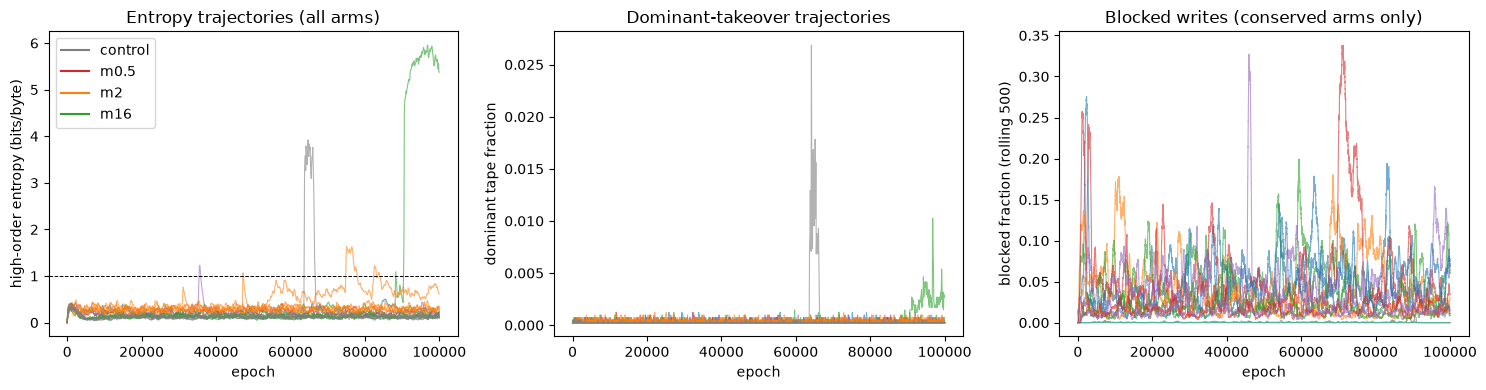

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
colors = {"control": "tab:gray", "m0.5": "tab:red", "m2": "tab:orange", "m16": "tab:green"}
for run_dir, (aggregate, _) in trajectories.items():
    arm = "control" if "control" in run_dir else ("m" + run_dir.split("_m")[1].split("_")[0])
    color = colors.get(arm, None)
    axes[0].plot(aggregate["epoch"], aggregate["high_order_entropy"], color=color, alpha=0.6, lw=0.8)
    axes[1].plot(aggregate["epoch"], aggregate["dominant_tape_fraction"], color=color, alpha=0.6, lw=0.8)
for run_dir, (_, writes) in trajectories.items():
    if writes is None:
        continue
    blocked = (writes["execution_writes_blocked"] + writes["mutation_writes_blocked"])
    attempted = (writes["execution_writes_success"] + writes["execution_writes_blocked"] + writes["mutation_writes_success"] + writes["mutation_writes_blocked"])
    roll = (blocked / attempted.replace(0, np.nan)).rolling(500, min_periods=1).mean()
    axes[2].plot(writes["epoch"], roll, alpha=0.6, lw=0.8)
axes[0].axhline(1.0, color="k", ls="--", lw=0.7)
axes[0].set_ylabel("high-order entropy (bits/byte)"); axes[0].set_title("Entropy trajectories (all arms)")
axes[1].set_ylabel("dominant tape fraction"); axes[1].set_title("Dominant-takeover trajectories")
axes[2].set_ylabel("blocked fraction (rolling 500)"); axes[2].set_title("Blocked writes (conserved arms only)")
for ax in axes:
    ax.set_xlabel("epoch")
handles = [plt.Line2D([], [], color=c, label=k) for k, c in colors.items()]
axes[0].legend(handles=handles)
plt.tight_layout(); plt.show()

## 4. Experiment B — conserved continuation of a natural replicator ecology

In [8]:
rows_b = []
control_csv = CONTROL_DIR / "B_control_continuation.csv"
if control_csv.exists():
    rows_b.append(load_control(control_csv, arm="control_continuation", seed=0))
for run_dir in sorted(CONTINUATION.glob("p1_m*_n131072_s0*")):
    manifest = json.loads((run_dir / "manifest.json").read_text())
    if manifest.get("exit_status") != "success":
        continue
    row = load_conserved(run_dir)
    row["kind"] = "continuation" if "initial_soup" in manifest["config"] else "baseline"
    if row["kind"] == "continuation":
        row["arm"] += "_continuation"
    else:
        row["arm"] += "_baseline"
    writes = row["_writes"]
    head = writes.head(1000)
    row["first_1000_blocked_fraction"] = (head["execution_writes_blocked"] + head["mutation_writes_blocked"]).sum() / max(1, (head["execution_writes_success"] + head["execution_writes_blocked"] + head["mutation_writes_success"] + head["mutation_writes_blocked"]).sum())
    rows_b.append(row)
b_runs = pd.DataFrame([{k: v for k, v in row.items() if not k.startswith("_")} for row in rows_b])
b_trajectories = {row["run_dir"]: (row["_aggregate"], row["_writes"]) for row in rows_b}
print(f"Experiment B: {len(b_runs)} completed runs")
b_runs.drop(columns=[c for c in ("overall_blocked_fraction",) if c not in b_runs.columns], errors="ignore")

Experiment B: 5 completed runs


,arm,kind,seed,epochs,entropy_transition,first_transition_epoch,max_high_order_entropy,final_high_order_entropy,max_dominant_fraction,final_dominant_fraction,overall_blocked_fraction,run_dir,first_1000_blocked_fraction
0,control_continuation,control,0,81,True,1.0,6.105359,5.803862,0.001396,0.000908,0.000000e+00,reports/phase1_newexperiments/B_control_contin...,NaN
1,m0.5_continuation,continuation,0,8000,True,1.0,6.051230,5.952791,0.001175,0.000641,5.838973e-06,experiments/phase1_runs/continuation/p1_m0p5_n...,1.774107e-06
2,m16_continuation,continuation,0,8000,True,1.0,6.105359,5.803862,0.001396,0.000908,0.000000e+00,experiments/phase1_runs/continuation/p1_m16_n1...,0.000000e+00
3,m2_baseline,baseline,0,8000,False,NaN,0.379540,0.300651,0.000099,0.000031,1.589155e-02,experiments/phase1_runs/continuation/p1_m2_n13...,7.585256e-03
4,m2_continuation,continuation,0,8000,True,1.0,6.109554,6.046322,0.001320,0.000908,2.559966e-07,experiments/phase1_runs/continuation/p1_m2_n13...,1.411288e-07


### B1 — control continuation completes takeover

In [9]:
bc = b_runs[b_runs["arm"] == "control_continuation"]
if len(bc):
    final_dom = float(bc["final_dominant_fraction"].iloc[0])
    final_ent = float(bc["final_high_order_entropy"].iloc[-1]) if "final_high_order_entropy" in bc else float(bc["final_high_order_entropy"].iloc[0])
    print(f"B1: control final dominant fraction = {final_dom:.4f}, final entropy = {final_ent:.3f}")
    print(f"     decision: {'SUPPORTED' if final_dom > 0.5 and final_ent > 1.0 else 'NOT SUPPORTED (B2/B3 uninterpretable)'}")
else:
    print("B1: control continuation not finished yet")

B1: control final dominant fraction = 0.0009, final entropy = 5.804
     decision: NOT SUPPORTED (B2/B3 uninterpretable)


### B2 / B3 — intermediate disruption, loose neutrality

In [10]:
for arm, label, criterion in [("m2_continuation", "B2 (disrupts takeover)", None), ("m16_continuation", "B3 (loose conservation neutral)", 0.5)]:
    sub = b_runs[b_runs["arm"] == arm]
    if not len(sub):
        print(f"{label}: run not finished yet")
        continue
    final_dom = float(sub["final_dominant_fraction"].iloc[0])
    final_ent = float(sub["final_high_order_entropy"].iloc[0])
    print(f"{label}: final dominant fraction = {final_dom:.4f}, final entropy = {final_ent:.3f} bits/byte")

B2 (disrupts takeover): final dominant fraction = 0.0009, final entropy = 6.046 bits/byte
B3 (loose conservation neutral): final dominant fraction = 0.0009, final entropy = 5.804 bits/byte


### B4 — replicator demand concentrates scarcity (first-1000-epoch blocked fraction, moving-block bootstrap)

In [11]:
m2c = b_runs[b_runs["arm"] == "m2_continuation"]
base = b_runs[b_runs["arm"] == "m2_baseline"]
if len(m2c) and len(base):
    writes_cont = b_trajectories[m2c["run_dir"].iloc[0]][1]
    writes_base = b_trajectories[base["run_dir"].iloc[0]][1]

    def per_epoch_blocked(w: pd.DataFrame) -> np.ndarray:
        attempted = w["execution_writes_success"] + w["execution_writes_blocked"] + w["mutation_writes_success"] + w["mutation_writes_blocked"]
        blocked = w["execution_writes_blocked"] + w["mutation_writes_blocked"]
        return (blocked / attempted.replace(0, np.nan)).fillna(0.0).to_numpy()

    cont_series, base_series = per_epoch_blocked(writes_cont.head(1000)), per_epoch_blocked(writes_base.head(1000))
    diff, lo, hi = block_bootstrap_difference(cont_series, base_series, block=100, samples=2000)
    print(f"B4: continuation first-1000 mean blocked = {cont_series.mean():.4f}")
    print(f"     random-soup baseline first-1000 mean blocked = {base_series.mean():.4f}")
    print(f"     difference = {diff:+.4f}, 95% moving-block bootstrap CI = [{lo:+.4f}, {hi:+.4f}]")
else:
    print("B4: continuation/baseline runs not finished yet")

B4: continuation first-1000 mean blocked = 0.0000
     random-soup baseline first-1000 mean blocked = 0.0077
     difference = -0.0077, 95% moving-block bootstrap CI = [-0.0121, -0.0032]


## 5. Experiment B trajectories

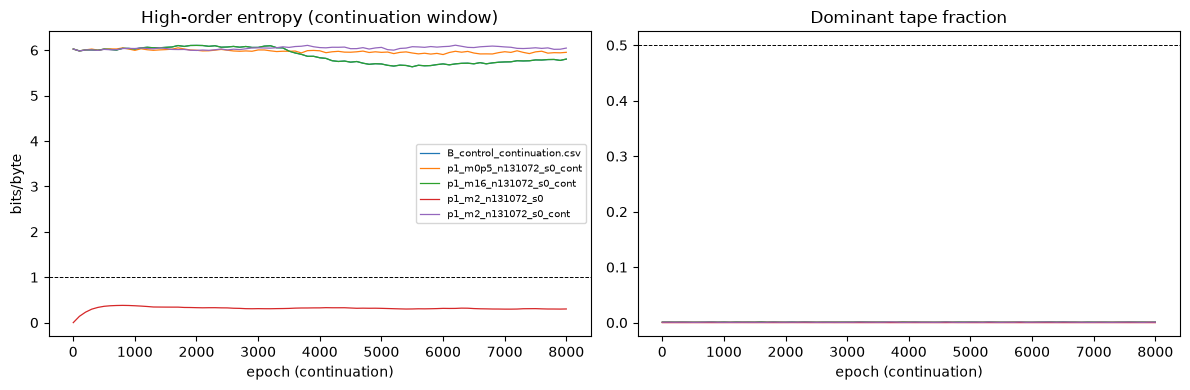

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for run_dir, (aggregate, _) in b_trajectories.items():
    axes[0].plot(aggregate["epoch"], aggregate["high_order_entropy"], lw=0.9, label=run_dir.split("/")[-1])
    axes[1].plot(aggregate["epoch"], aggregate["dominant_tape_fraction"], lw=0.9)
axes[0].axhline(1.0, color="k", ls="--", lw=0.7)
axes[0].set_title("High-order entropy (continuation window)"); axes[0].set_ylabel("bits/byte")
axes[1].set_title("Dominant tape fraction"); axes[1].axhline(0.5, color="k", ls="--", lw=0.7)
for ax in axes:
    ax.set_xlabel("epoch (continuation)")
axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 6. Summary

Hypothesis decisions are also written to `reports/phase1_newexperiments_report.md`
by `uv run python -m experiments.analyze_phase1_newexperiments`. Interpretation
notes and caveats live in the final report; this notebook only reports the
preregistered statistics.